### **1. Importing Libraries**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### **2. Loading the Data**

In [24]:
transform = transforms.Compose([
    transforms.ToTensor()
])

dataset_path = './tiny-imagenet/train'

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
print(f"Loaded {len(dataset)} images from {dataset_path}")

Loaded 3500 images from ./tiny-imagenet/train


### **3. Defining Nosie Functions**

In [25]:
def gauss_noise(images, mean=0.0, std=0.2):
    noise = torch.randn(images.size()) *std + mean
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0., 1.)

def salt_pepp_noise(images, amount=0.05):
    noisy_images = images.clone()
    p = amount / 2.0
    
    salt_mask = torch.rand(images.size()) < p
    noisy_images[salt_mask] = 1.0
    
    pepper_mask = torch.rand(images.size()) < p
    noisy_images[pepper_mask] = 0.0
    
    return noisy_images

### **4. Creating the AutoEncoder**

In [26]:
class DAE(nn.Module):
    def __init__(self):
        super(DAE, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DAE().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### **5. Training and Loss**

Epoch [1/30], MSE Loss: 0.0209
Epoch [2/30], MSE Loss: 0.0142
Epoch [3/30], MSE Loss: 0.0128
Epoch [4/30], MSE Loss: 0.0119
Epoch [5/30], MSE Loss: 0.0116
Epoch [6/30], MSE Loss: 0.0111
Epoch [7/30], MSE Loss: 0.0109
Epoch [8/30], MSE Loss: 0.0107
Epoch [9/30], MSE Loss: 0.0106
Epoch [10/30], MSE Loss: 0.0102
Epoch [11/30], MSE Loss: 0.0101
Epoch [12/30], MSE Loss: 0.0101
Epoch [13/30], MSE Loss: 0.0099
Epoch [14/30], MSE Loss: 0.0099
Epoch [15/30], MSE Loss: 0.0097
Epoch [16/30], MSE Loss: 0.0097
Epoch [17/30], MSE Loss: 0.0097
Epoch [18/30], MSE Loss: 0.0096
Epoch [19/30], MSE Loss: 0.0094
Epoch [20/30], MSE Loss: 0.0094
Epoch [21/30], MSE Loss: 0.0093
Epoch [22/30], MSE Loss: 0.0093
Epoch [23/30], MSE Loss: 0.0092
Epoch [24/30], MSE Loss: 0.0092
Epoch [25/30], MSE Loss: 0.0091
Epoch [26/30], MSE Loss: 0.0091
Epoch [27/30], MSE Loss: 0.0090
Epoch [28/30], MSE Loss: 0.0088
Epoch [29/30], MSE Loss: 0.0090
Epoch [30/30], MSE Loss: 0.0089


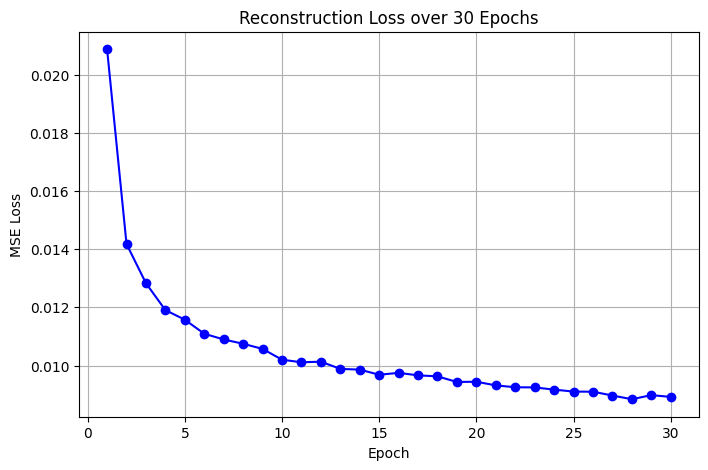

In [27]:
epochs = 30
noise_type = "gaussian"

epoch_losses = []

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for img, _ in dataloader:
        
        if noise_type == "gaussian":
            noisy_img = gauss_noise(img)
        else:
            noisy_img = salt_pepp_noise(img)
            
        img, noisy_img = img.to(device), noisy_img.to(device)
        
        optimizer.zero_grad()
        outputs = model(noisy_img)
        
        loss = criterion(outputs, img) 
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(dataloader)
    epoch_losses.append(avg_loss) # Save it
    
    print(f"Epoch [{epoch+1}/{epochs}], MSE Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', linestyle='-', color='b')
plt.title('Reconstruction Loss over 30 Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

### **6. Comparing Output with Original Images**

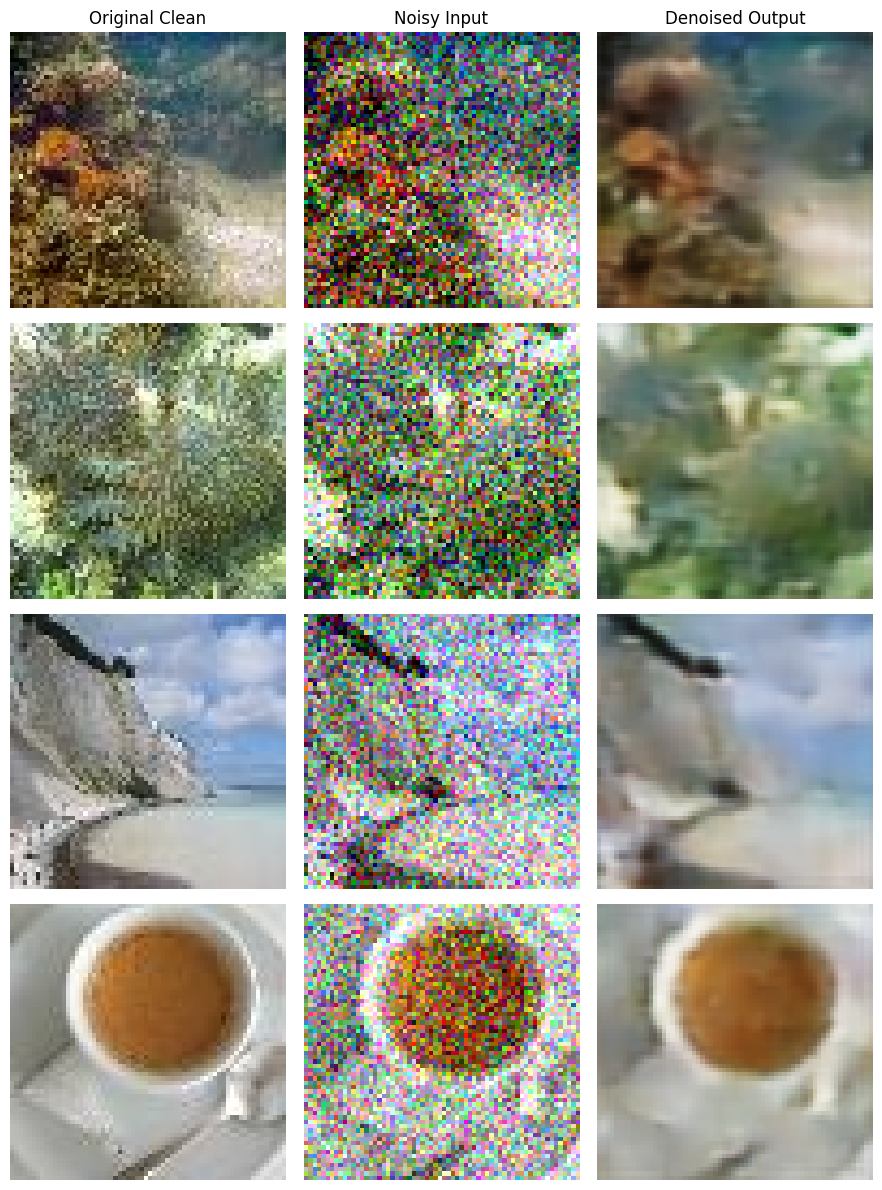

In [28]:
model.eval()

images, _ = next(iter(dataloader))

if noise_type == "gaussian":
    noisy_images = gauss_noise(images)
else:
    noisy_images = salt_pepp_noise(images)

images = images.to(device)
noisy_images = noisy_images.to(device)

with torch.no_grad():
    denoised_images = model(noisy_images)

def imshow(img, title):
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(9, 12))
for i in range(4):
    plt.subplot(4, 3, i * 3 + 1)
    imshow(images[i], "Original Clean" if i == 0 else "")
    
    plt.subplot(4, 3, i * 3 + 2)
    imshow(noisy_images[i], "Noisy Input" if i == 0 else "")
    
    plt.subplot(4, 3, i * 3 + 3)
    imshow(denoised_images[i], "Denoised Output" if i == 0 else "")

plt.tight_layout()
plt.show()